# Light Leak Analysis

We investigate the nature of the light leak here with the following data sets: 

1) Observations taken on 26-02-16 with the array blanked off
2) Obseravtions taken on 26-02-03 with of the sky and the CVF set to "blocking"

In [1]:
# Import all the necessary libraries
%run install_packages.py
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry 
from test_analysis import read_in_fits
from analysis_functions import * 

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


Here, we take the data from the sky at zenith, the blocking fitler in at zenith, the 

In [2]:
# Import data

# Array temp for the data set was 6.2K
zenith_sky_1_data = read_in_fits('./data/260203/zenith_sky_1')
zenith_blanked_sky_data = read_in_fits('./data/260203/zenith_dark')
HAM_blanked_sky_data = read_in_fits('./data/260203/highAM_dark')

# Take the warmest data sets since you'd expect the most noise from those. (Data sets 4 and 5 at 9.0 and 8.5 K respectively)
dark_4_data = read_in_fits('./data/260216/dark4')
dark_5_data = read_in_fits('./data/260216/dark5')

# But the array at dark 1 is comparable to the array temp at the telescope the night the data was taken so we'll also analyze that data set.
dark_1_data = read_in_fits('./data/260216/dark1')


Processing 1500 FITS files from ./data/260203/zenith_sky_1
Loaded 1500 FITS files from ./data/260203/zenith_sky_1
Processing 1500 FITS files from ./data/260203/zenith_dark
Loaded 1500 FITS files from ./data/260203/zenith_dark
Processing 1500 FITS files from ./data/260203/highAM_dark
Loaded 1500 FITS files from ./data/260203/highAM_dark
Processing 1500 FITS files from ./data/260216/dark4
Loaded 1500 FITS files from ./data/260216/dark4
Processing 1500 FITS files from ./data/260216/dark5
Loaded 1500 FITS files from ./data/260216/dark5
Processing 1500 FITS files from ./data/260216/dark1
Loaded 1500 FITS files from ./data/260216/dark1


From prior work we know that that the values start to settle around frame 200. 

In [3]:
TRIM_FRAMES = (199,-1)

COADDS = np.arange(5,251)

## Check the frequency content 

In [4]:
zenith_sky_data_channels = extract_channels(zenith_sky_1_data, channel_width=20, trim=TRIM_FRAMES)
zenith_sky_variances, zenith_sky_t_dwell, zenith_sky_f_state, zenith_sky_f_coadd = create_variance_curve(zenith_sky_data_channels["channels"], COADDS, frame_dt_s=0.0103)

zenith_blanked_sky_data_channels = extract_channels(zenith_blanked_sky_data, channel_width=20, trim=TRIM_FRAMES)
zenith_blanked_sky_variances, zenith_blanked_sky_t_dwell, zenith_blanked_sky_f_state, zenith_blanked_sky_f_coadd = create_variance_curve(zenith_blanked_sky_data_channels["channels"], COADDS, frame_dt_s=0.0103)

dark_1_data_channels = extract_channels(dark_1_data, channel_width=20, trim=TRIM_FRAMES)
dark_1_variances, dark_1_t_dwell, dark_1_f_state, dark_1_f_coadd = create_variance_curve(dark_1_data_channels["channels"], COADDS, frame_dt_s=0.0113)

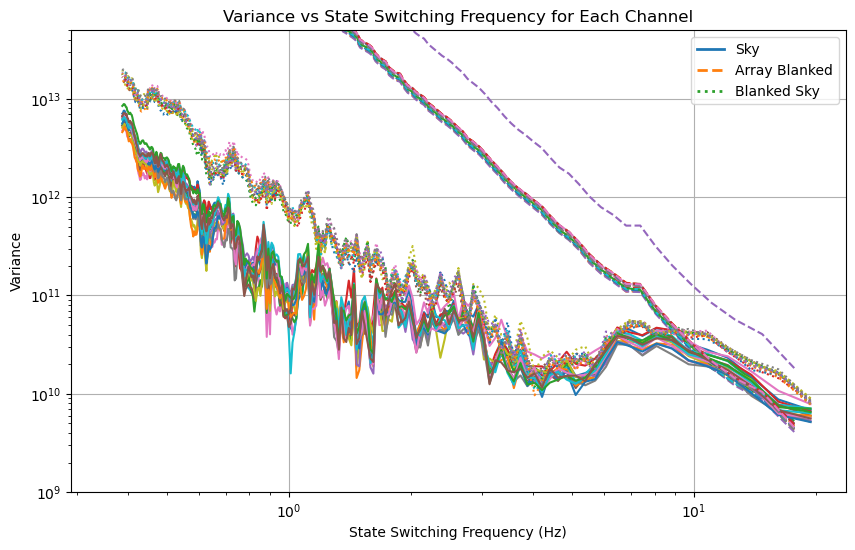

In [5]:
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 6))
for channel in range(zenith_sky_data_channels["channels"].shape[0]): 
    variances_ch = [zenith_sky_variances[n][channel] for n in COADDS]
    variances_dark_ch = [dark_1_variances[n][channel] for n in COADDS]
    variances_blanked_ch = [zenith_blanked_sky_variances[n][channel] for n in COADDS]
    plt.plot(zenith_sky_f_state, variances_ch)
    plt.plot(dark_1_f_state, variances_dark_ch, ls='--')
    plt.plot(zenith_blanked_sky_f_state, variances_blanked_ch, ls=':')

plt.xlabel('State Switching Frequency (Hz)')
plt.ylabel('Variance')
plt.title('Variance vs State Switching Frequency for Each Channel')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e13)

# Create legend with just line styles
legend_elements = [Line2D([0], [0], color='C0', lw=2, label='Sky'),
                   Line2D([0], [0], color='C1', lw=2, linestyle='--', label='Array Blanked'),
                   Line2D([0], [0], color='C2', lw=2, linestyle=':', label='Blanked Sky')]
plt.legend(handles=legend_elements)
plt.grid()
plt.show()

This plot computes the variance as a function of the state switching frequency. For the most comparable array temperatures the red noise of the detector is evident here.

Now, take the worst case, where the array is the warmest and we'd expect the most red noise. 

In [6]:
dark_4_data_channels = extract_channels(dark_4_data, channel_width=20, trim=TRIM_FRAMES)
dark_4_variances, dark_4_t_dwell, dark_4_f_state, dark_4_f_coadd = create_variance_curve(dark_4_data_channels["channels"], COADDS, frame_dt_s=0.0113)
dark_5_data_channels = extract_channels(dark_5_data, channel_width=20, trim=TRIM_FRAMES)
dark_5_variances, dark_5_t_dwell, dark_5_f_state, dark_5_f_coadd = create_variance_curve(dark_5_data_channels["channels"], COADDS, frame_dt_s=0.0113)   

In [7]:
# Plot the high airmass data against the zenith data 
highAM_data_channels = extract_channels(HAM_blanked_sky_data, channel_width=20, trim=TRIM_FRAMES)
highAM_variances, highAM_t_dwell, highAM_f_state, highAM_f_coadd = create_variance_curve(highAM_data_channels["channels"], COADDS, frame_dt_s=0.0103)


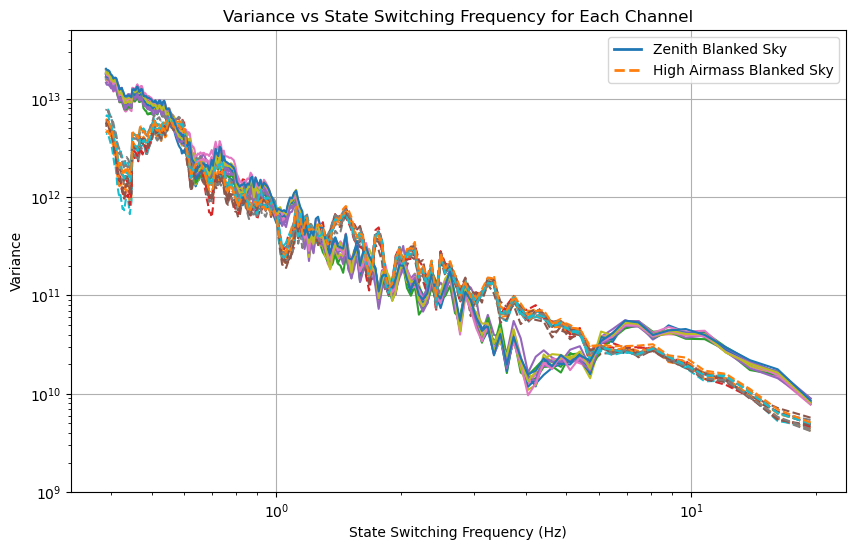

In [8]:
plt.figure(figsize=(10, 6))
for channel in range(zenith_sky_data_channels["channels"].shape[0]):
    variances_ch = [zenith_blanked_sky_variances[n][channel] for n in COADDS]
    variances_highAM_ch = [highAM_variances[n][channel] for n in COADDS]
    plt.plot(zenith_blanked_sky_f_state, variances_ch)
    plt.plot(highAM_f_state, variances_highAM_ch, ls='--') 
plt.xlabel('State Switching Frequency (Hz)')
plt.ylabel('Variance')
plt.title('Variance vs State Switching Frequency for Each Channel')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e13) 
# Create legend with just line styles
legend_elements = [Line2D([0], [0], color='C0', lw=2, label='Zenith Blanked Sky'),
                   Line2D([0], [0], color='C1', lw=2, linestyle='--', label='High Airmass Blanked Sky')]
plt.legend(handles=legend_elements)
plt.grid()
plt.show()

So it seems the that the noise also changes as a function of airmass when blanked off... but why could this be? 

Now compare to the "noisest" case - where we expect a lot of red noise from the detector

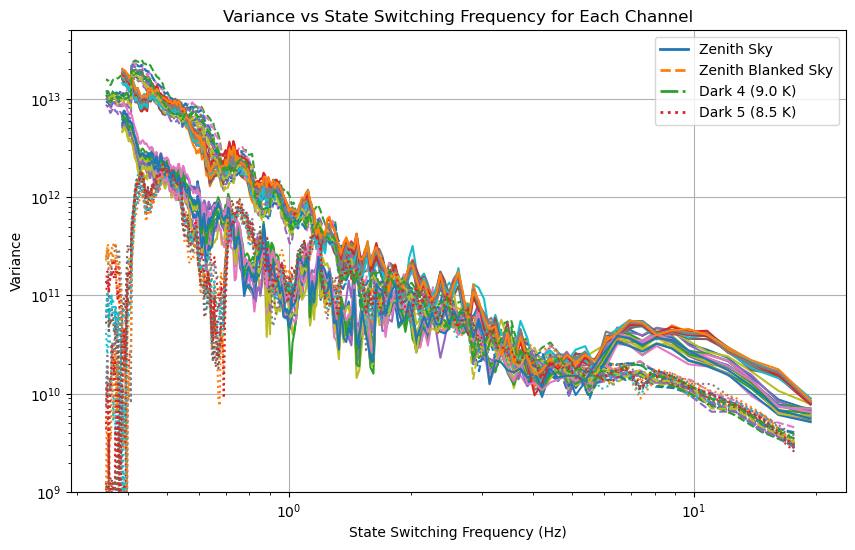

In [9]:
# Plot variance curves for zenith sky and blanked, 4, and 5 to see if the warmer data sets have higher variance as expected
plt.figure(figsize=(10, 6))
for channel in range(zenith_sky_data_channels["channels"].shape[0]):
    variances_sky = [zenith_sky_variances[n][channel] for n in COADDS]
    variances_blanked_ch = [zenith_blanked_sky_variances[n][channel] for n in COADDS]
    variances_dark4_ch = [dark_4_variances[n][channel] for n in COADDS]
    variances_dark5_ch = [dark_5_variances[n][channel] for n in COADDS]
    plt.plot(zenith_sky_f_state, variances_sky)
    plt.plot(zenith_blanked_sky_f_state, variances_blanked_ch)
    plt.plot(dark_4_f_state, variances_dark4_ch, ls='--')
    plt.plot(dark_5_f_state, variances_dark5_ch, ls=':')

plt.xlabel('State Switching Frequency (Hz)')
plt.ylabel('Variance')
plt.title('Variance vs State Switching Frequency for Each Channel')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e13)
# Create legend with just line styles
legend_elements = [Line2D([0], [0], color='C0', lw=2, label='Zenith Sky'),
                   Line2D([0], [0], color='C1', lw=2, linestyle='--', label='Zenith Blanked Sky'),
                     Line2D([0], [0], color='C2', lw=2, linestyle='-.', label='Dark 4 (9.0 K)'),
                     Line2D([0], [0], color='C3', lw=2, linestyle=':', label='Dark 5 (8.5 K)')]
plt.legend(handles=legend_elements)
plt.grid()
plt.show()

This plot looks kinda messy - what if we just take the average over the channels for each of the values

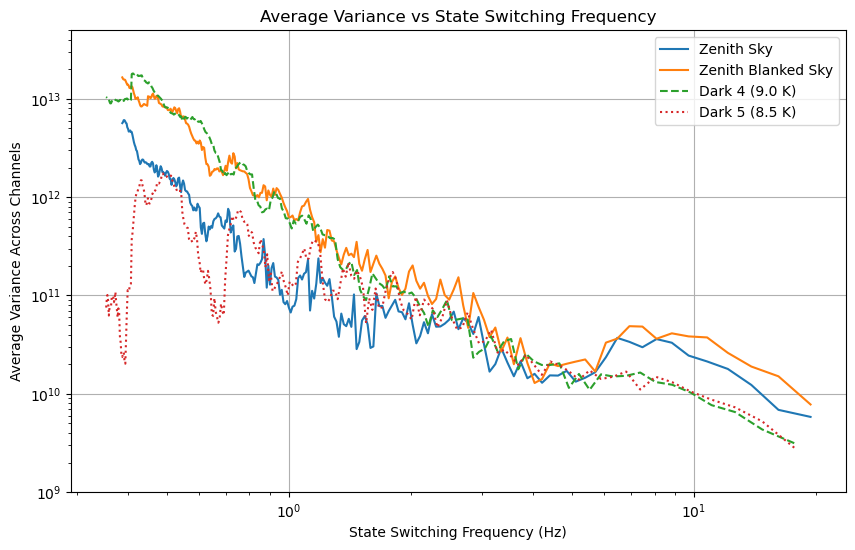

In [10]:
plt.figure(figsize=(10, 6))

# Average over all channels for each coaddition
avg_variance_sky = [np.mean([zenith_sky_variances[n][channel] for channel in range(zenith_sky_data_channels["channels"].shape[0])]) for n in COADDS]
avg_variance_blanked = [np.mean([zenith_blanked_sky_variances[n][channel] for channel in range(zenith_blanked_sky_data_channels["channels"].shape[0])]) for n in COADDS]
avg_variance_dark4 = [np.mean([dark_4_variances[n][channel] for channel in range(dark_4_data_channels["channels"].shape[0])]) for n in COADDS]
avg_variance_dark5 = [np.mean([dark_5_variances[n][channel] for channel in range(dark_5_data_channels["channels"].shape[0])]) for n in COADDS]

plt.plot(zenith_sky_f_state, avg_variance_sky, label='Zenith Sky')
plt.plot(zenith_blanked_sky_f_state, avg_variance_blanked, label='Zenith Blanked Sky')
plt.plot(dark_4_f_state, avg_variance_dark4, label='Dark 4 (9.0 K)', ls='--')
plt.plot(dark_5_f_state, avg_variance_dark5, label='Dark 5 (8.5 K)', ls=':')

plt.xlabel('State Switching Frequency (Hz)')
plt.ylabel('Average Variance Across Channels')
plt.title('Average Variance vs State Switching Frequency')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e9, 5e13)
plt.legend()
plt.grid()

So, the frames taken with the sky have a noticable increase in variance around the 6 Hz mark 

## Check the count distributions

Next, we can look at the count distributions. For each column, make a histogram of the counts. This is over all the frames taken.

In [11]:
# I think there's a problem - the pixel counts are way higher than the number of pixels in the array, so I think the variance is being calculated incorrectly.

# print the shape of the 3rd channel in the zenith sky data to see how many pixels there are
print(zenith_sky_data_channels["channels"][2].shape)

(1300, 240, 20)


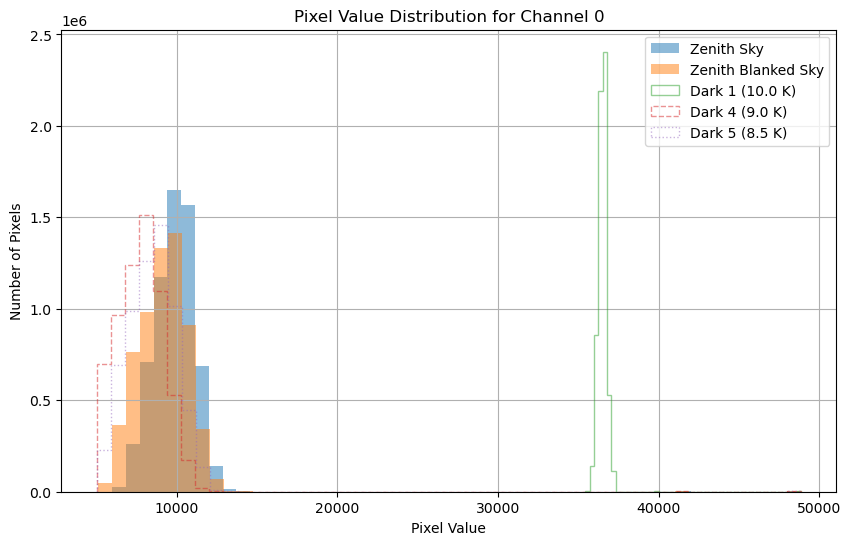

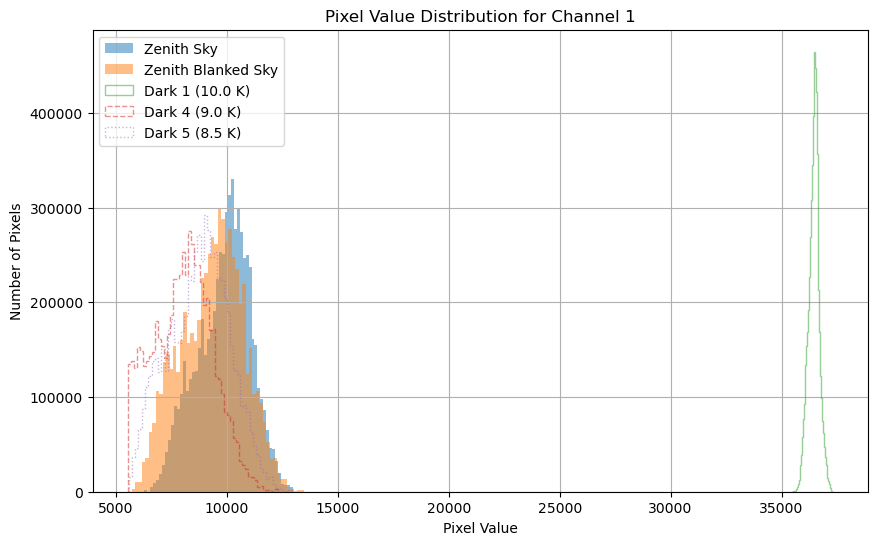

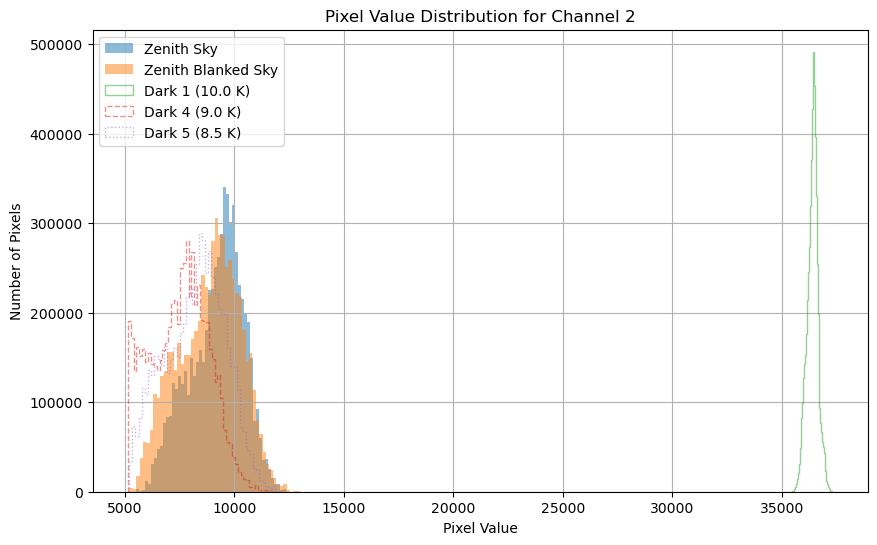

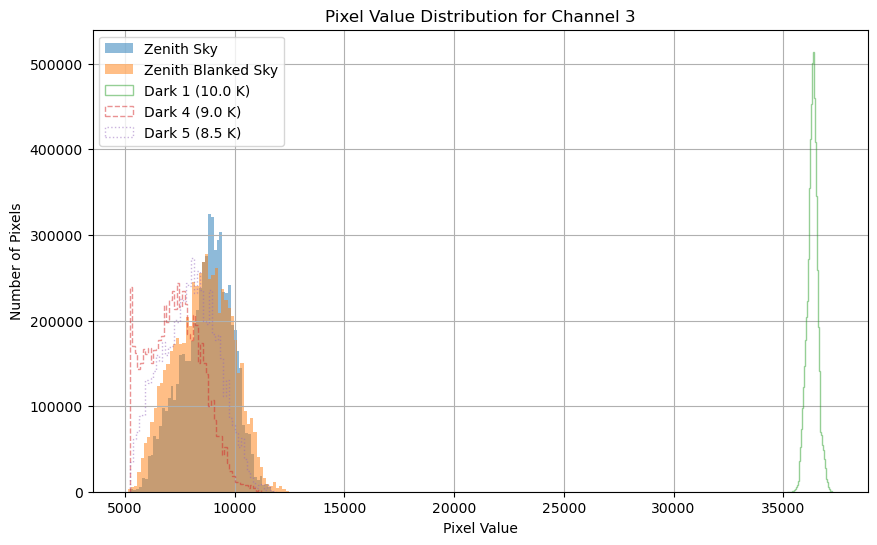

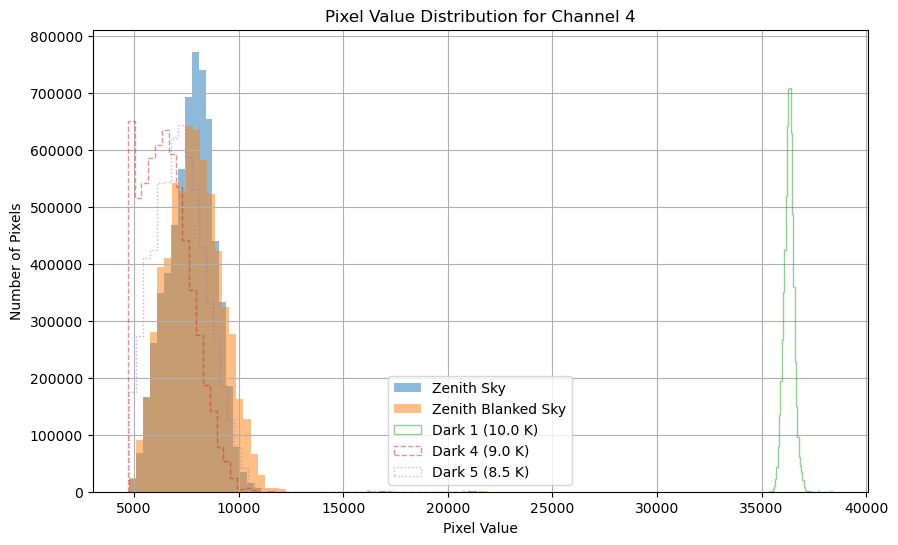

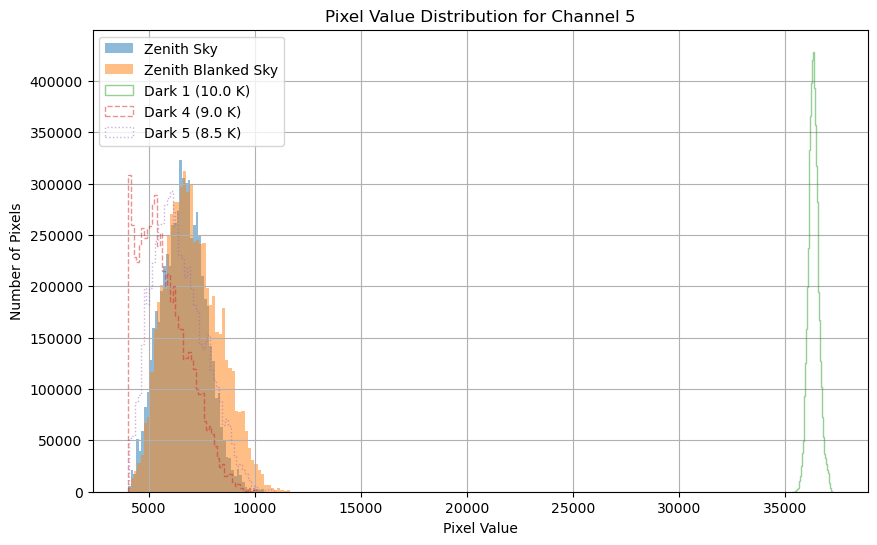

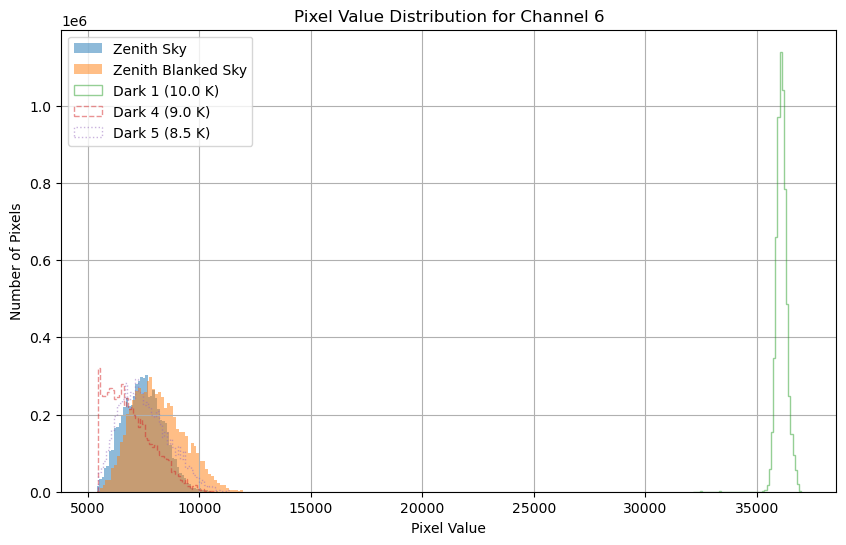

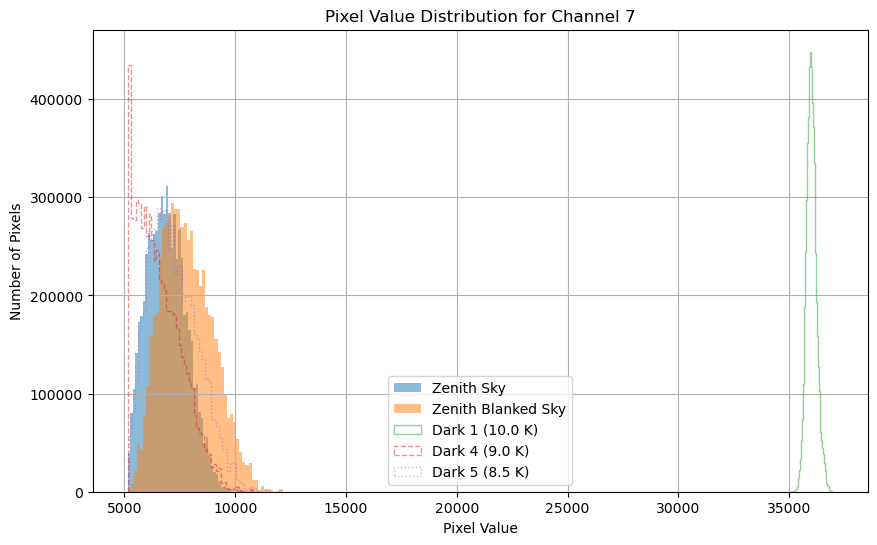

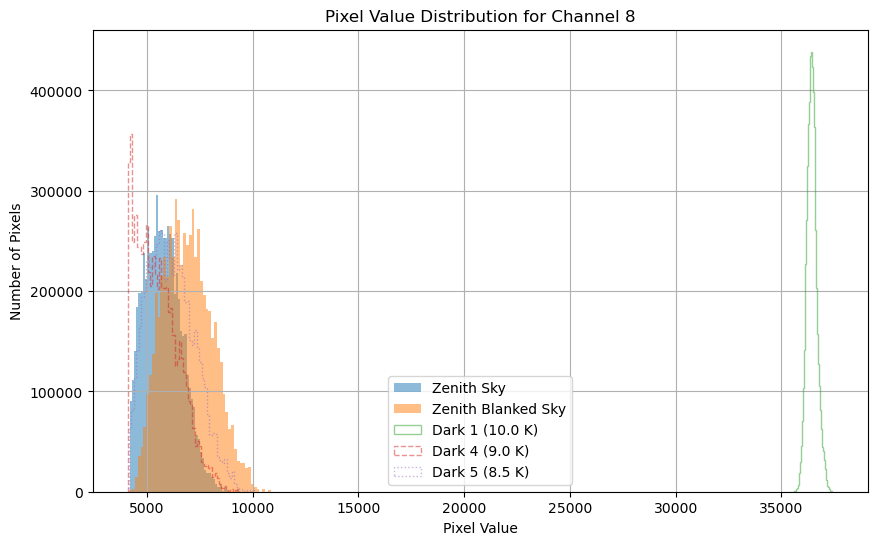

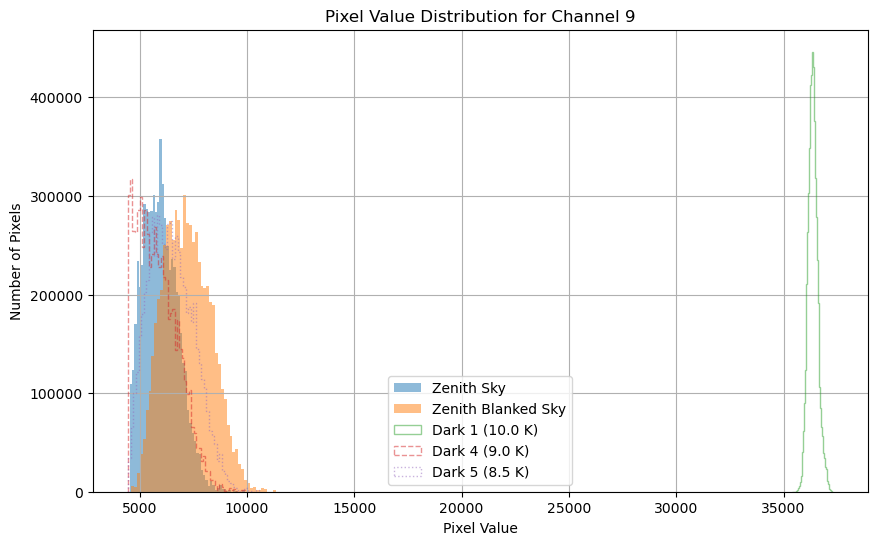

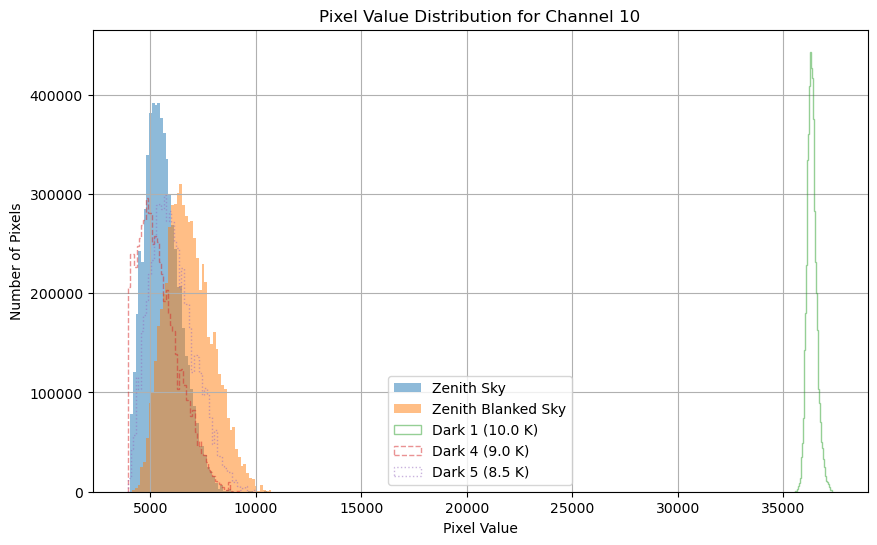

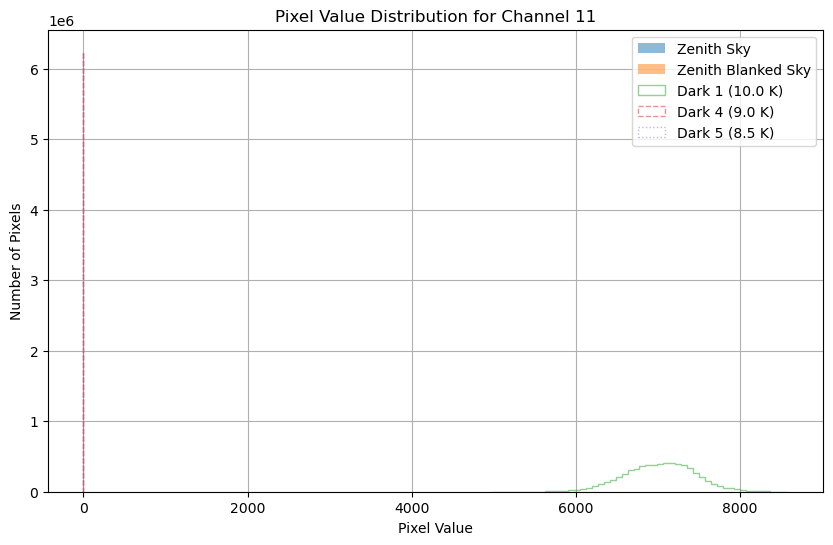

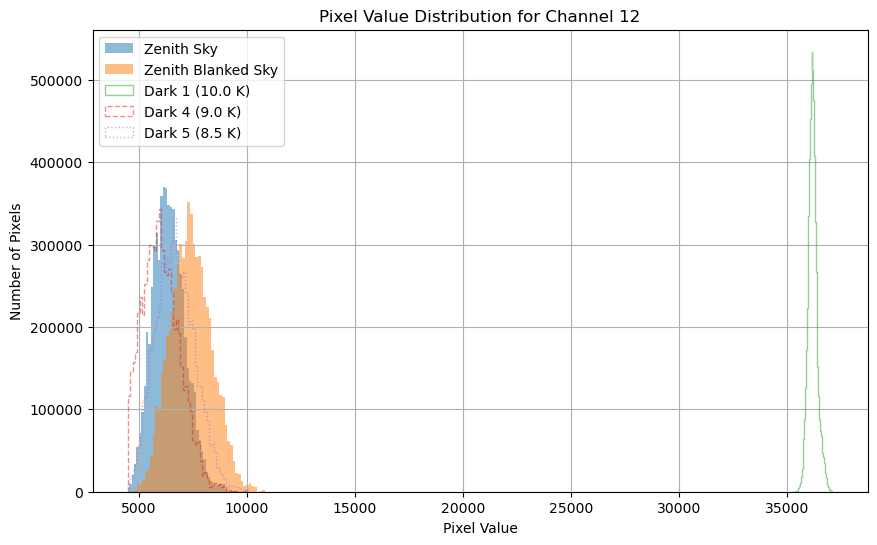

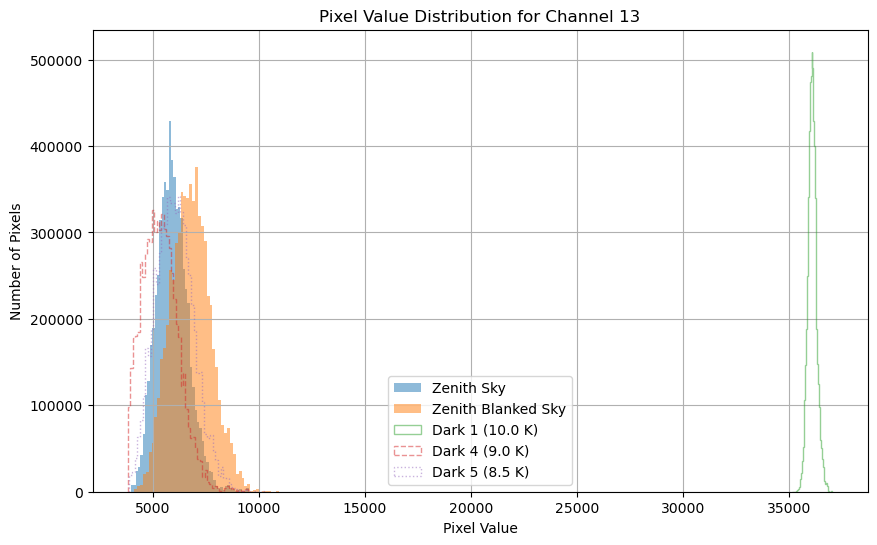

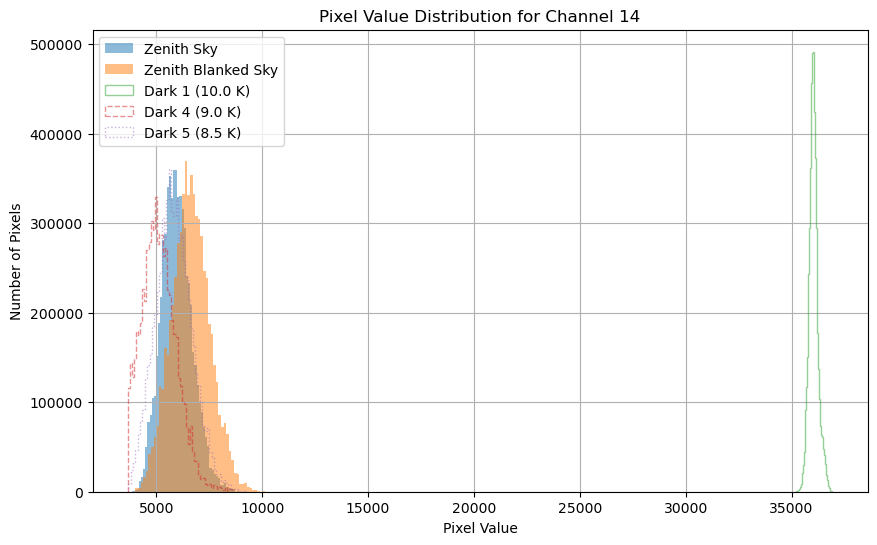

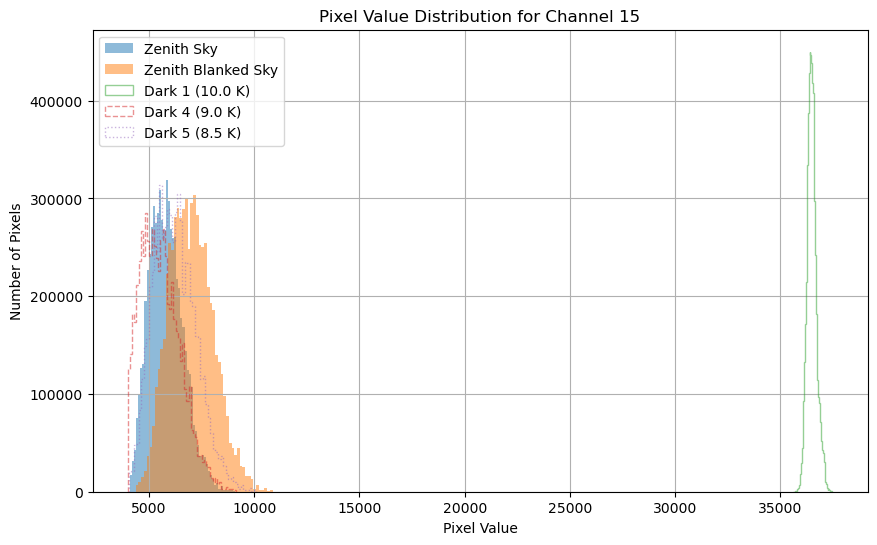

In [36]:
# Loop through the columns and make a histogram of the pixel values 
for channel in range(zenith_sky_data_channels["channels"].shape[0]):
    plt.figure(figsize=(10, 6))
    pixel_values_sky = zenith_sky_data_channels["channels"][channel].flatten()
    pixel_values_blanked = zenith_blanked_sky_data_channels["channels"][channel].flatten()
    pixel_values_dark1 = dark_1_data_channels["channels"][channel].flatten()
    pixel_values_dark4 = dark_4_data_channels["channels"][channel].flatten()
    pixel_values_dark5 = dark_5_data_channels["channels"][channel].flatten()
    
    plt.hist(pixel_values_sky, bins=50, alpha=0.5, label='Zenith Sky')
    plt.hist(pixel_values_blanked, bins=50, alpha=0.5, label='Zenith Blanked Sky')
    plt.hist(pixel_values_dark1, bins=50, alpha=0.5, label='Dark 1 (10.0 K)', histtype='step', linestyle='-')
    plt.hist(pixel_values_dark4, bins=50, alpha=0.5, label='Dark 4 (9.0 K)', histtype='step', linestyle='--')
    plt.hist(pixel_values_dark5, bins=50, alpha=0.5, label='Dark 5 (8.5 K)', histtype='step', linestyle=':')
    
    plt.xlabel('Pixel Value')
    plt.ylabel('Number of Pixels')
    plt.title(f'Pixel Value Distribution for Channel {channel}')
    plt.legend()
    plt.grid()
    plt.show()


Pretty convincing signs for a light leak present in MIRSI. Will need to see about the other data first.